In [1]:
import pandas as pd
import numpy as np
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from pathlib import Path

In [1]:
current_dir = Path.cwd()
insert_dir = os.path.join(current_dir , '..' , 'models-architecture');
sys.path.insert(0 ,insert_dir)

print(insert_dir)

NameError: name 'Path' is not defined

In [11]:
from ncf import NeuralCollaborativeFramework

In [14]:
rname = ['user_id' , 'movie_id', 'rating','timestamp']
ratings_df = pd.read_csv('../../data/mv-lens-1m/ratings.dat', delimiter = '::',header=None, engine='python' , names=rname)

ratings_df.head()

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [16]:
num_users = ratings_df['user_id'].nunique()
num_movies = ratings_df['movie_id'].nunique()

print(num_users , num_movies)

6040 3706


In [ ]:
model = NeuralCollaborativeFramework(num_users , num_movies)
print(f"ncf model architecture {model}")

ncf model architecture NeuralCollaborativeFramework(
  (user_embedding): Embedding(6040, 32)
  (movie_embedding): Embedding(3706, 32)
  (MLP): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [ ]:
from torch.utils.data import Dataset, DataLoader

# Prepare data tensors (convert user and movie ids to zero-based indices)
user_ids = torch.tensor(ratings_df['user_id'].values - 1, dtype=torch.long)
movie_ids = torch.tensor(ratings_df['movie_id'].values - 1, dtype=torch.long)


ratings = torch.tensor(ratings_df['rating'].values.astype(np.float32), dtype=torch.float32)

num_samples = len(ratings)
indices = torch.randperm(num_samples)
split = int(0.8 * num_samples)

train_indices = indices[:split]
val_indices = indices[split:]


class RatingsDataset(Dataset):
    def __init__(self, user_ids, movie_ids, ratings, indices):
        self.user_ids = user_ids[indices]
        self.movie_ids = movie_ids[indices]
        self.ratings = ratings[indices]

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return (
            self.user_ids[idx],
            self.movie_ids[idx],
            self.ratings[idx],
        )

train_dataset = RatingsDataset(user_ids, movie_ids, ratings, train_indices)
val_dataset = RatingsDataset(user_ids, movie_ids, ratings, val_indices)
batch_size = 1024

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


movie_batch, user_batch, rating_batch = next(iter(train_loader))


tensor([1103, 1324, 4057,  ..., 1915, 5688, 5770]) tensor([ 734, 2986,  291,  ..., 2457,  377, 1224]) tensor([3., 5., 4.,  ..., 3., 3., 4.])


In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3 , )

num_epochs = 10

history = {"train_rmse": [], "val_rmse": []}

for epoch in range(1, num_epochs + 1):
    model.train()
    train_squared_loss = 0.0

    for batch_user, batch_movie, batch_rating in train_loader:
        batch_user = batch_user.to(device)
        batch_movie = batch_movie.to(device)
        batch_rating = batch_rating.to(device)

        optimizer.zero_grad()
        outputs = model(batch_user, batch_movie).squeeze()
        loss = criterion(outputs, batch_rating)
        loss.backward()
        optimizer.step()

        train_squared_loss += loss.item() * batch_rating.size(0)

    train_mse = train_squared_loss / len(train_loader.dataset)
    train_rmse = train_mse ** 0.5

    model.eval()
    val_squared_loss = 0.0

    with torch.no_grad():
        for batch_user, batch_movie, batch_rating in val_loader:
            batch_user = batch_user.to(device)
            batch_movie = batch_movie.to(device)
            batch_rating = batch_rating.to(device)

            outputs = model(batch_user, batch_movie).squeeze()
            loss = criterion(outputs, batch_rating)

            val_squared_loss += loss.item() * batch_rating.size(0)

    val_mse = val_squared_loss / len(val_loader.dataset)
    val_rmse = val_mse ** 0.5

    history["train_rmse"].append(train_rmse)
    history["val_rmse"].append(val_rmse)

    print(f"Epoch {epoch}/{num_epochs} - Train RMSE: {train_rmse:.4f} - Val RMSE: {val_rmse:.4f}")


Epoch 1/10 - Train RMSE: 0.9341 - Val RMSE: 0.9031
Epoch 2/10 - Train RMSE: 0.8921 - Val RMSE: 0.8919
Epoch 3/10 - Train RMSE: 0.8768 - Val RMSE: 0.8851
Epoch 4/10 - Train RMSE: 0.8651 - Val RMSE: 0.8845
Epoch 5/10 - Train RMSE: 0.8552 - Val RMSE: 0.8834
Epoch 6/10 - Train RMSE: 0.8455 - Val RMSE: 0.8842
Epoch 7/10 - Train RMSE: 0.8358 - Val RMSE: 0.8849
Epoch 8/10 - Train RMSE: 0.8257 - Val RMSE: 0.8868
Epoch 9/10 - Train RMSE: 0.8157 - Val RMSE: 0.8879
Epoch 10/10 - Train RMSE: 0.8055 - Val RMSE: 0.8915


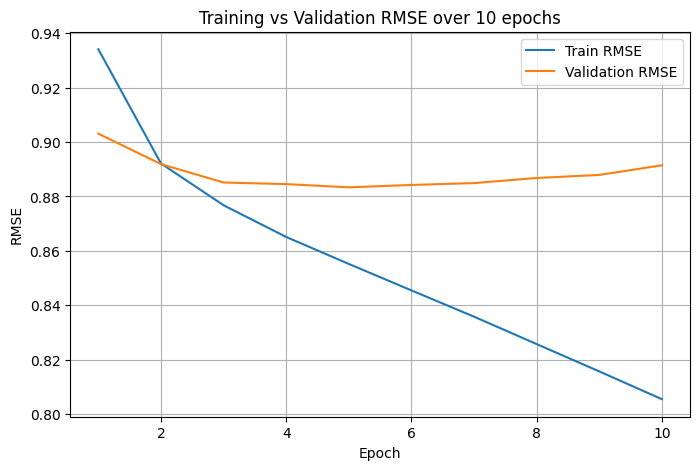

Final Train RMSE: 0.8054606362644766
Final Val RMSE: 0.8914607175568106


In [37]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_rmse"], label="Train RMSE")
plt.plot(epochs, history["val_rmse"], label="Validation RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Training vs Validation RMSE over 10 epochs")
plt.legend()
plt.grid(True)
plt.show()

print("Final Train RMSE:", history["train_rmse"][-1])
print("Final Val RMSE:", history["val_rmse"][-1])


# Overfitted